# 📺 *Suits* – A Brief Overview

##### ✍️ Ayetijhya Desmukhya  📅 18 May 2025  

---

**_Suits_** is a critically acclaimed American legal drama television series created by **Aaron Korsh**. The show premiered on **USA Network** on **June 23, 2011**, and ran for **nine seasons**, concluding on **September 25, 2019**.

Set in a high-powered New York law firm, *Suits* follows **Harvey Specter** (played by *Gabriel Macht*), a top corporate attorney, and his associate **Mike Ross** (played by *Patrick J. Adams*), a brilliant college dropout who never actually attended law school. The series explores their unconventional partnership as they navigate complex cases, office politics, and moral dilemmas — all while keeping Mike’s secret hidden.

Known for its **sharp writing**, **charismatic characters**, and **stylish tone**, *Suits* became one of **USA Network’s** most popular original series. It also gained renewed global popularity through streaming platforms years after its initial run.

---

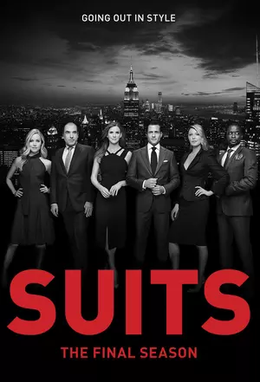

In [1]:
from IPython.display import Image
display(Image(filename='images/s9poster.png'))

## 🕸️ Web Scraping Process: *Suits* Viewership Data

To analyze the viewership trends of *Suits*, I extracted episode-level data from the official Wikipedia page:  
🔗 [List of Suits Episodes – Wikipedia](https://en.wikipedia.org/wiki/List_of_Suits_episodes)

---

### 🔧 Step-by-Step Breakdown

1. **Import Required Libraries**  
   We used:
   - `requests` to fetch the HTML content of the page.
   - `BeautifulSoup` from `bs4` to parse and navigate the HTML.
   - `pandas` to store the scraped data in tabular format.

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [3]:
url = 'https://en.wikipedia.org/wiki/List_of_Suits_episodes'
response = requests.get(url)
soup = BeautifulSoup(response.content, 'html.parser')

2. **Locate Episode Tables**  
   The Wikipedia page contains multiple `<table class="wikitable plainrowheaders wikiepisodetable">` elements — one for each season.  
   These tables list:
   - Episode titles  
   - Original air dates  
   - U.S. viewership numbers (in millions)

3. **Extract Viewership Data**  
   For each season table:
   - We looped through each row (`<tr>`)  
   - Extracted the episode number, title, air date, and viewership  
   - Converted viewership numbers to `float` for analysis

4. **Clean and Aggregate**  
   - Skipped rows without viewership data (e.g., headers or summaries)  
   - Removed references and footnotes from cells  

In [4]:
# Find all tables with class 'wikitable plainrowheaders wikiepisodetable'
tables = soup.find_all('table', class_='wikitable plainrowheaders wikiepisodetable')

all_data = []

for season_num, table in enumerate(tables):
    rows = table.find_all('tr')
    for row in rows[1:]:
        cells = row.find_all(['th', 'td'])
        if len(cells) >= 6:
            try:
                episode_num = cells[1].get_text(strip=True)
                title = cells[2].get_text(strip=True).strip('"')
                air_date = cells[5].get_text(strip=True)
                viewers_text = cells[6].get_text(strip=True)
                viewers = float(viewers_text[:viewers_text.find('[')])
                all_data.append({
                    'Season': season_num+1,
                    'Episode': episode_num,
                    'Title': title,
                    'AirDate': air_date,
                    'ViewersInMillions': viewers
                })
            except:
                print(exception)

5. **Store the Data**  
   - Compiled into a `pandas` DataFrame  
   - Saved to `.csv` format for easy access and plotting

In [5]:
# Create DataFrame
df = pd.DataFrame(all_data)
df.to_csv('data/suits_viewership_data.csv', index=False)

---

This structured data allows us to visualize and explore trends in *Suits*' popularity across its nine-season run.

## 📊 Summary of Basic Viewership Statistics

After scraping and aggregating viewership data for all episodes of *Suits* from [Wikipedia](https://en.wikipedia.org/wiki/List_of_Suits_episodes), we calculated the following basic statistics:

In [6]:
df.head()

,Season,Episode,Title,AirDate,ViewersInMillions
0,1,1,Pilot,"June 23, 2011(2011-06-23)",4.64
1,1,2,Errors and Omissions,"June 30, 2011(2011-06-30)",3.89
2,1,3,Inside Track,"July 7, 2011(2011-07-07)",4.53
3,1,4,Dirty Little Secrets,"July 14, 2011(2011-07-14)",4.38
4,1,5,Bail Out,"July 21, 2011(2011-07-21)",4.38


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Season             134 non-null    int64  
 1   Episode            134 non-null    object 
 2   Title              134 non-null    object 
 3   AirDate            134 non-null    object 
 4   ViewersInMillions  134 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 5.4+ KB


In [8]:
# Calculate average viewership per season
avg_viewership = df.groupby('Season')['ViewersInMillions'].mean().reset_index()

# Sort by Season to ensure correct order
avg_viewership = avg_viewership.sort_values('Season').reset_index(drop=True)

# Compute season-to-season differences
avg_viewership['Change'] = avg_viewership['ViewersInMillions'].diff()

# Find largest drop (most negative change)
largest_drop_row = avg_viewership.loc[avg_viewership['Change'].idxmin()]
largest_drop = round(largest_drop_row['Change'], 2)
largest_drop_season = int(largest_drop_row['Season'])

# Find smallest absolute drop or gain (ignoring zero or null)
change_non_null = avg_viewership['Change'].dropna()
smallest_change_index = change_non_null.abs().idxmin()
smallest_change_row = avg_viewership.loc[smallest_change_index]
smallest_change = round(smallest_change_row['Change'], 2)
smallest_change_season = int(smallest_change_row['Season'])

# Compute overall decline
overall_decline = round(avg_viewership['ViewersInMillions'].iloc[0] - avg_viewership['ViewersInMillions'].iloc[-1], 2)
start_season = int(avg_viewership['Season'].iloc[0])
end_season = int(avg_viewership['Season'].iloc[-1])

# Build the summary dictionary
summary_metrics = {
    "Number of Seasons": int(df["Season"].max()),
    "Total Episodes": df.groupby('Season').size().sum(),
    "Highest Avg Season Viewership": f"{round(avg_viewership['ViewersInMillions'].max(), 2)} million (Season {int(avg_viewership.loc[avg_viewership['ViewersInMillions'].idxmax()]['Season'])})",
    "Lowest Avg Season Viewership": f"{round(avg_viewership['ViewersInMillions'].min(), 2)} million (Season {int(avg_viewership.loc[avg_viewership['ViewersInMillions'].idxmin()]['Season'])})",
    "Largest Season-to-Season Drop": f"{largest_drop} million (Season {largest_drop_season - 1} ➝ {largest_drop_season})",
    "Smallest Drop / Gain": f"{smallest_change} million (Season {smallest_change_season - 1} ➝ {smallest_change_season})",
    "Overall Decline": f"{overall_decline} million (Season {start_season} ➝ {end_season})"
}

# Create summary DataFrame
summary_df = pd.DataFrame(summary_metrics.items(), columns=["Metric", "Value"])
summary_df


,Metric,Value
0,Number of Seasons,9
1,Total Episodes,134
2,Highest Avg Season Viewership,4.16 million (Season 1)
3,Lowest Avg Season Viewership,0.99 million (Season 9)
4,Largest Season-to-Season Drop,-0.88 million (Season 2 ➝ 3)
5,Smallest Drop / Gain,-0.03 million (Season 8 ➝ 9)
6,Overall Decline,3.17 million (Season 1 ➝ 9)


---

These numbers reflect a steady decline in viewership over time, with the first few seasons maintaining strong ratings and later seasons seeing a gradual dip in audience size — possibly due to cast changes, plot fatigue, or platform shifts.


## 📊 Viewership Trends

### 1. A Graph of the Viewership Over Time
This graph shows how the average viewership evolved from one season to the next. It provides a clear picture of overall trends—whether the audience grew, declined, or remained stable throughout the series.

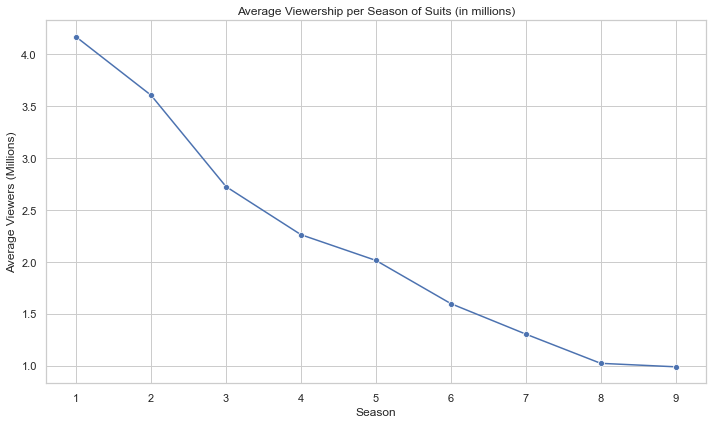

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average viewership per season
avg_viewership = df.groupby('Season')['ViewersInMillions'].mean().reset_index()

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(data=avg_viewership, x='Season', y='ViewersInMillions', marker='o')
plt.title('Average Viewership per Season of Suits (in millions)')
plt.xlabel('Season')
plt.ylabel('Average Viewers (Millions)')
plt.xticks(avg_viewership['Season'])
plt.tight_layout()
plt.show()


### 2. A Graph of Episode-to-Episode Changes in Viewership
This graph highlights the **differences in viewership between consecutive episodes**, helping to pinpoint where major drops or gains occurred. It's useful for identifying pivotal shifts in audience engagement.


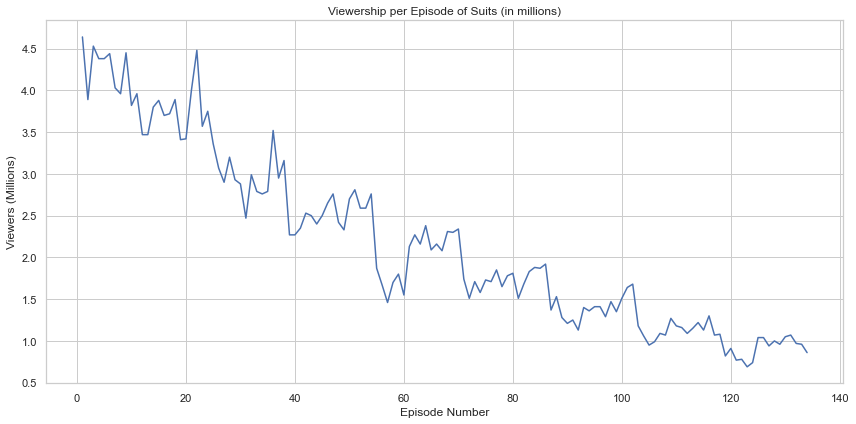

In [10]:
# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=range(1, len(df)+1), y='ViewersInMillions')
plt.title('Viewership per Episode of Suits (in millions)')
plt.xlabel('Episode Number')
plt.ylabel('Viewers (Millions)')
plt.tight_layout()
plt.show()

## Results

### 1. 🎬 General Stats
- **Number of Seasons:** 9
- **Total Episodes:** 134

*Suits* ran for nearly a decade, delivering a total of 134 episodes across 9 seasons. It maintained a consistent release schedule and a loyal fanbase, despite viewership shifts.

### 2. 🔝 Highest & Lowest Average Viewership
- **Highest Avg Season Viewership:** **4.16 million** *(Season 1)*
- **Lowest Avg Season Viewership:** **0.99 million** *(Season 9)*

The series started off strong, debuting with a solid average of **4.16 million** viewers in its first season. Over time, however, viewership declined, reaching its lowest point in **Season 9**, with just **0.99 million** average viewers — a drop of over 75% from its peak.

### 3. 📉 Largest Season-to-Season Drop
- **Drop:** **-0.88 million** *(Season 2 ➝ 3)*

The most dramatic decline occurred between **Season 2 and Season 3**, where the average audience shrank by nearly **0.9 million viewers**. This marks a critical turning point in the show’s popularity.

### 4. 🔁 Smallest Drop / Gain
- **Change:** **-0.03 million** *(Season 8 ➝ 9)*

Interestingly, the viewership remained relatively steady between **Season 8 and 9**, with only a **30,000-viewer** decrease. Despite the overall decline by this stage, the show retained a core group of committed viewers to the end.

### 5. 📉 Overall Decline
- **Decline:** **3.17 million** *(Season 1 ➝ 9)*

Across its entire run, *Suits* lost approximately **3.17 million** average viewers, declining from a high of **4.16 million** to under **1 million**. While this trend reflects a common arc in long-running TV shows, it also underscores the importance of narrative momentum and evolving audience preferences.

---

These metrics illustrate how *Suits* captivated viewers early on, faced mid-series attrition, and ultimately ended with a smaller yet consistent audience. The data offers a compelling narrative of audience engagement over time.
